# 15. Категории с тысячей значений: пять способов подать их бустингу

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`15_categorical_encodings.py`](../15_categorical_encodings.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 15 с |

**Цель.** Выбрать способ кодирования высококардинальной категории по данным, а не по привычке.

### Чему вы научитесь

- Числовые коды
- one-hot для частых значений
- `TargetEncoder` из sklearn — кодирование средним с перекрёстной подгонкой, без утечки
- Встроенные категории LightGBM и CatBoost
- Сравнение по качеству и времени

### Данные

30 000 заказов интернет-магазина (синтетика): товар (1000 значений с убывающей частотой — много редких), цена, скидка, день недели; цель — вернут ли товар (класс 1 у ~10%). Возврат зависит от товара.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Пять способов (LightGBM с ранней остановкой, кроме CatBoost)
3. **Этап 3.** Качество на тесте (чем меньше log-loss и больше AUC — тем лучше)
4. **Этап 4.** Выводы

> Ноутбук собран из `examples/3_medium/15_categorical_encodings.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "3_medium/15_categorical_encodings.py", title="15. Категории с тысячей значений: пять способов",
             goal="сравнить способы кодирования высококардинальной категории")

import time

import catboost as cb
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder

## Этап 1. Данные

In [2]:
r = np.random.default_rng(15)
n, K = ex.size(30_000, 8000), 1000
p_item = 1 / np.arange(1, K + 1) ** 0.8
p_item /= p_item.sum()
item = r.choice(K, n, p=p_item)
item_effect = np.random.default_rng(150).normal(0, 1.0, K)
price = np.exp(r.normal(7, 0.8, n))
discount = r.choice([0, 10, 20, 30, 50], n, p=[0.5, 0.2, 0.15, 0.1, 0.05])
dow = r.integers(0, 7, n)
z = -2.6 + item_effect[item] + 0.25 * (np.log(price) - 7) + 0.02 * discount + 0.2 * (dow >= 5)
y = (r.random(n) < 1 / (1 + np.exp(-z))).astype(int)
X = pd.DataFrame({"товар": pd.Categorical(item.astype(str)), "цена": price.round(0), "скидка": discount, "день_недели": dow})
ex.describe(X, y, target="возврат", task="classification", source="синтетика: у каждого товара своя склонность к возврату")
counts = pd.Series(item).value_counts()
print(f"   значений у «товар»: {X['товар'].nunique()}; встречаются реже 10 раз: {(counts < 10).sum()}")
perm = r.permutation(n)
tr, va, te = perm[: int(0.6 * n)], perm[int(0.6 * n): int(0.8 * n)], perm[int(0.8 * n):]
num = ["цена", "скидка", "день_недели"]


def lgb_fit(Xtr, Xva, Xte, **kw):
    m = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.05, verbose=-1, random_state=0, **kw)
    m.fit(Xtr, y[tr], eval_X=(Xva,), eval_y=(y[va],), callbacks=[lgb.early_stopping(100, verbose=False)])
    return m.predict_proba(Xte)[:, 1]

   Источник: синтетика: у каждого товара своя склонность к возврату
   Объектов: 30 000   признаков: 4   память: 0.79 МБ
   Типы признаков: int64 × 2, category × 1, float64 × 1
   Пропусков нет
   Цель «возврат»: класс 0 — 26338 (87.8%), класс 1 — 3662 (12.2%)
   Первые строки:


,товар,цена,скидка,день_недели,[возврат]
0,255,383.0,0,0,0
1,461,819.0,10,4,0
2,27,1512.0,30,0,0


   значений у «товар»: 1000; встречаются реже 10 раз: 248


## Этап 2. Пять способов (LightGBM с ранней остановкой, кроме CatBoost)

In [3]:
results = {}
codes = X.assign(товар=X["товар"].cat.codes)
t = time.perf_counter()
results["числовые коды"] = (lgb_fit(codes.iloc[tr], codes.iloc[va], codes.iloc[te]), time.perf_counter() - t)

top = counts.index[:50].astype(str)
oh = pd.get_dummies(X["товар"].astype(str).where(X["товар"].astype(str).isin(top), "прочие"), prefix="т", dtype=float)
Xoh = pd.concat([X[num], oh], axis=1)
t = time.perf_counter()
results["one-hot 50 частых + «прочие»"] = (lgb_fit(Xoh.iloc[tr], Xoh.iloc[va], Xoh.iloc[te]), time.perf_counter() - t)

t = time.perf_counter()
enc = TargetEncoder(target_type="binary", cv=KFold(5, shuffle=True, random_state=0))
te_tr = enc.fit_transform(X[["товар"]].iloc[tr], y[tr])          # перекрёстная подгонка — без утечки
Xte_ = lambda idx: np.c_[enc.transform(X[["товар"]].iloc[idx]), X[num].iloc[idx]]
results["TargetEncoder (sklearn)"] = (lgb_fit(np.c_[te_tr, X[num].iloc[tr]], Xte_(va), Xte_(te)), time.perf_counter() - t)

t = time.perf_counter()
results["встроенные категории LightGBM"] = (lgb_fit(X.iloc[tr], X.iloc[va], X.iloc[te], cat_smooth=20), time.perf_counter() - t)

t = time.perf_counter()
Xs = X.assign(товар=X["товар"].astype(str))
cbm = cb.CatBoostClassifier(iterations=2000, learning_rate=0.1, early_stopping_rounds=100, verbose=0, random_seed=0,
                            allow_writing_files=False)
cbm.fit(cb.Pool(Xs.iloc[tr], y[tr], cat_features=["товар"]), eval_set=cb.Pool(Xs.iloc[va], y[va], cat_features=["товар"]))
results["CatBoost (упорядоченные статистики)"] = (cbm.predict_proba(cb.Pool(Xs.iloc[te], cat_features=["товар"]))[:, 1], time.perf_counter() - t)

## Этап 3. Качество на тесте (чем меньше log-loss и больше AUC — тем лучше)

   способ                                  log-loss     AUC  время, с
   числовые коды                             0.3712  0.6316       0.2
   one-hot 50 частых + «прочие»              0.3678  0.6385       0.1
   TargetEncoder (sklearn)                   0.3577  0.6926       0.1
   встроенные категории LightGBM             0.3641  0.6640       0.1
   CatBoost (упорядоченные статистики)       0.3558  0.6956      12.5
   (константа)                               0.3834
   лучший: CatBoost (упорядоченные статистики); худший: числовые коды


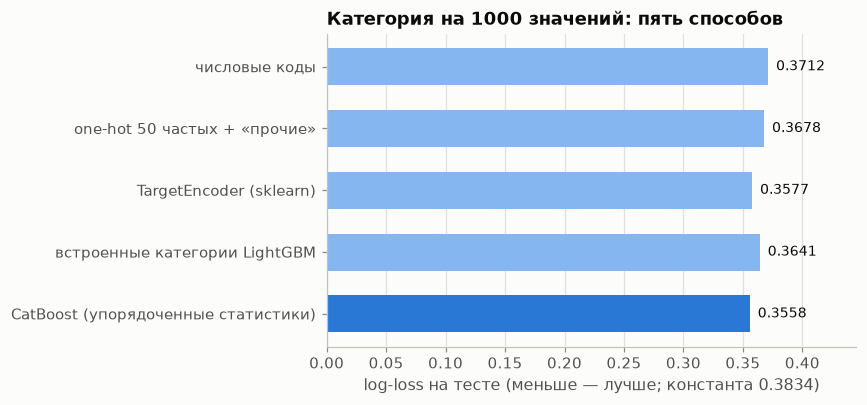

In [4]:
base = log_loss(y[te], np.full(len(te), y[tr].mean()))
print(f"   {'способ':38s} {'log-loss':>9s} {'AUC':>7s} {'время, с':>9s}")
for name, (p, sec) in results.items():
    print(f"   {name:38s} {log_loss(y[te], p):9.4f} {roc_auc_score(y[te], p):7.4f} {sec:9.1f}")
print(f"   {'(константа)':38s} {base:9.4f}")
best = min(results, key=lambda k: log_loss(y[te], results[k][0]))
worst = max(results, key=lambda k: log_loss(y[te], results[k][0]))
print(f"   лучший: {best}; худший: {worst}")
ll = {k: log_loss(y[te], p) for k, (p, _) in results.items()}
ex.barh(ll, best=best, name="15_encodings_logloss", fmt="{:.4f}",
        xlabel=f"log-loss на тесте (меньше — лучше; константа {base:.4f})", title="Категория на 1000 значений: пять способов")

## Этап 4. Выводы

In [5]:
ex.note("""Числовые коды заставляют дерево делить товары по случайному порядку номеров — много разбиений ради одной группы.
One-hot 50 частых значений теряет информацию обо всех редких товарах.
Кодирование средним с перекрёстной подгонкой и встроенные методы используют всю категорию — какой из них лучше,
зависит от данных (урок 10.1); проверяйте на валидации.""")
ex.done()

> ▸ **Вывод.** Числовые коды заставляют дерево делить товары по случайному порядку номеров — много разбиений ради одной группы. One-hot 50 частых значений теряет информацию обо всех редких товарах. Кодирование средним с перекрёстной подгонкой и встроенные методы используют всю категорию — какой из них лучше, зависит от данных (урок 10.1); проверяйте на валидации.

Готово за 14.0 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Сделайте разброс эффектов товаров 0.3 или 2.0 вместо 1.0 — как меняется разрыв между способами?
2. Кодируйте one-hot 200 самых частых товаров вместо 50.
3. Посчитайте кодирование средним «наивно» — по всей обучающей выборке без перекрёстной подгонки — и найдите утечку.

## Что дальше

- **Теория в курсе:** [10.1 «Категориальные признаки»](../../../lessons/lesson_10_1/README.md), [9.3 «CatBoost»](../../../lessons/lesson_9_3/README.md).
- **Предыдущий пример:** [14. HistGradientBoosting из scikit-learn: бустинг без дополнительных библиотек](14_sklearn_hist_gbm.ipynb)
- **Следующий пример:** [16. Пропуски: три механизма и четыре способа обработки](16_missing_values.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)